In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 2.1/351.2 MB 4.2 MB/s eta 0:01:23
   ---------------------------------------- 3.1/351.2 MB 4.4 MB/s eta 0:01:20
    --------------------------------------- 5.0/351.2 MB 5.4 MB/s eta 0:01:05
    --------------------------------------- 6.6/351.2 MB 5.7 MB/s eta 0:01:00
    --------------------------------------- 8.7/351.2 MB 6.3 MB/s eta 0:00:55
   - -------------------------------------- 10.7/351.2 MB 6.9 MB/s eta 0:00:50
   - -------------------------------------- 12.8/351.2 MB 7.2 MB/s eta 0:00:47
   - -------------------------------------- 14.9/351.2 MB 7.5 MB/s eta 0:00:45
   - -------------------------------------- 17.0/351.2 MB 7.8 MB/s eta 0:00:44
   -- ------------------------------------- 19.4/351.2 MB 8.0 MB/s eta 0:0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [3]:
pip install protobuf==3.20.3

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 3.20.3 which is incompatible.


Columns: ['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu', 'mjob', 'fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences', 'g1', 'g2', 'g3']
Using column: pstatus

Classification Accuracy: 1.0


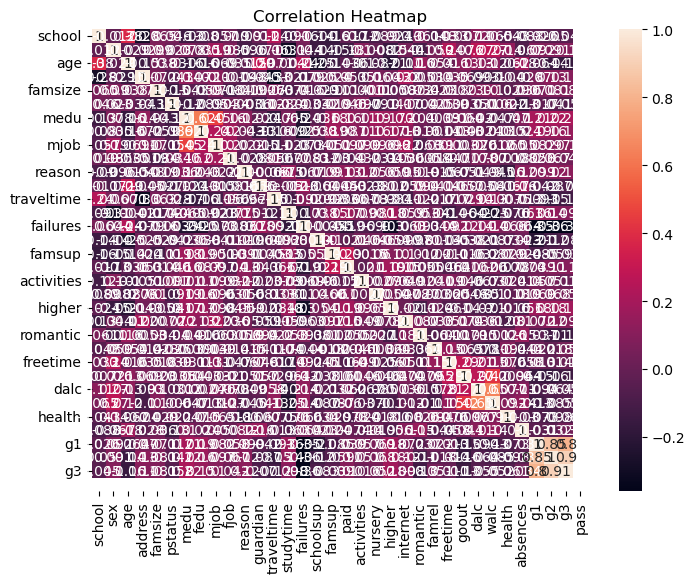

In [4]:
# ===================== IMPORTS =====================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# ===================== LOAD DATA =====================
df = pd.read_csv("StudentsPerformance.csv")

# ===================== CLEAN COLUMN NAMES =====================
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns.tolist())

# ===================== REMOVE NULL =====================
df = df.dropna()

# ===================== ENCODE CATEGORICAL =====================
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ===================== SELECT TARGET COLUMN =====================
# 👉 change index if needed after seeing printed columns
math_col = df.columns[5]

print("Using column:", math_col)

# ===================== CREATE CLASSIFICATION TARGET =====================
df['pass'] = df[math_col].apply(lambda x: 1 if x >= 40 else 0)

# ===================== FEATURES =====================
X = df.drop([math_col, 'pass'], axis=1)
y = df['pass']

# ===================== SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ===================== MODEL =====================
model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)
model.fit(X_train, y_train)

# ===================== RESULT =====================
print("\nClassification Accuracy:", model.score(X_test, y_test))

# ===================== VISUALIZATION =====================
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()